# AAL3 labels on Cedalion Colin27 and ICBM152

This notebook mirrors the Schaefer parcel plotting workflow, but uses AAL3 labels. The AAL JSON file is only a lookup table from integer label values to region names. To color a cortex mesh, we also need a vertex-to-AAL assignment. This notebook can create that assignment from the AAL NIfTI files once, save it as CSV, and then reuse the CSV for plotting without re-reading the NIfTI files.

In [2]:
from pathlib import Path
import json

import cedalion.dot
import cedalion.vis.blocks as vbx
import nibabel as nib
import numpy as np
import pandas as pd
import pyvista as pv
from scipy.ndimage import distance_transform_edt, map_coordinates
from scipy.spatial import KDTree

pv.set_jupyter_backend("static")

In [3]:
AAL_DIR = Path(r"C:\Users\mayucel\Documents\CODE\atlas\aal_mapping_sharedwithEike")
AAL_JSON = AAL_DIR / "aal_labels.json"

# AAL3 SPM12 source atlas in Colin/MNI305-aligned space.
AAL_COLIN_NII = AAL_DIR / "ROI_MNI_V7_1mm.nii"

OUT_COLIN = AAL_DIR / "aal3_colin27_vertex_labels.csv"

# Set True if you changed atlas paths or want to overwrite stale CSVs.
FORCE_REGENERATE = True

# Surface vertices can land just outside a labeled atlas voxel. Fill only those
# background samples that are very close to a nonzero AAL voxel.
FILL_BACKGROUND_FROM_NEAREST_AAL = True
MAX_BACKGROUND_FILL_DISTANCE_MM = 2.0

## Load AAL label names

This JSON alone is not enough to map AAL onto a head model. It tells us what label index `1`, `2`, etc. mean, but not which Colin27 or ICBM152 surface vertices belong to each label.

In [4]:
with AAL_JSON.open("r", encoding="utf-8") as fin:
    aal_info = json.load(fin)

aal_name = {0: "Background"}
aal_name.update({int(item["index"]): item["name"] for item in aal_info["labels"]})

pd.DataFrame(aal_info["labels"]).head()

,index,name
0,1,Precentral_L
1,2,Precentral_R
2,3,Frontal_Sup_2_L
3,4,Frontal_Sup_2_R
4,5,Frontal_Mid_2_L


## Create vertex-to-AAL CSVs

Run this section once when the CSV files do not exist or when `FORCE_REGENERATE = True`. The Colin labels are sampled from the AAL3 SPM12 source atlas; ICBM labels are transferred from Colin by nearest MNI152 surface vertex.

In [5]:
def sample_volume_at_points(label_nii, points_ras, fill_background=False):
    img = nib.load(label_nii)
    data = img.get_fdata()
    vox = nib.affines.apply_affine(np.linalg.inv(img.affine), points_ras).T
    labels = map_coordinates(data, vox, order=0, mode="constant", cval=0)
    labels = np.rint(labels).astype(int)

    if fill_background and np.any(labels == 0):
        nonzero = data != 0
        voxel_sizes = np.asarray(img.header.get_zooms()[:3], dtype=float)
        distances, nearest = distance_transform_edt(
            ~nonzero, sampling=voxel_sizes, return_indices=True
        )

        bg = labels == 0
        ijk = np.rint(vox[:, bg]).astype(int)
        in_bounds = (
            (ijk[0] >= 0) & (ijk[0] < data.shape[0]) &
            (ijk[1] >= 0) & (ijk[1] < data.shape[1]) &
            (ijk[2] >= 0) & (ijk[2] < data.shape[2])
        )
        bg_indices = np.where(bg)[0]

        ijk_in = ijk[:, in_bounds]
        bg_indices_in = bg_indices[in_bounds]
        close = distances[ijk_in[0], ijk_in[1], ijk_in[2]] <= MAX_BACKGROUND_FILL_DISTANCE_MM

        if np.any(close):
            close_ijk = ijk_in[:, close]
            nearest_ijk = nearest[:, close_ijk[0], close_ijk[1], close_ijk[2]]
            labels[bg_indices_in[close]] = data[
                nearest_ijk[0], nearest_ijk[1], nearest_ijk[2]
            ].astype(int)

    return labels


def colin_native_vertex_coordinates(head):
    coords = head.brain.vertices.points.apply_transform(head.t_ijk2ras).pint.dequantify()
    return coords.label.values, coords.values


def mni152_vertex_coordinates(head):
    coords = head.get_brain_mni152_coords()
    return coords.label.values, coords.values


def make_aal_vertex_csv(model, label_nii, out_csv, coordinate_mode):
    head = cedalion.dot.get_standard_headmodel(model)
    if coordinate_mode == "colin_native":
        vertex, coords = colin_native_vertex_coordinates(head)
    elif coordinate_mode == "mni152":
        vertex, coords = mni152_vertex_coordinates(head)
    else:
        raise ValueError(coordinate_mode)

    aal_index = sample_volume_at_points(
        label_nii, coords, fill_background=FILL_BACKGROUND_FROM_NEAREST_AAL
    )
    df = pd.DataFrame({
        "vertex": vertex,
        "model": model,
        "coordinate_mode": coordinate_mode,
        "source_nifti": str(label_nii),
        "r": coords[:, 0],
        "a": coords[:, 1],
        "s": coords[:, 2],
        "aal_index": aal_index,
        "aal_name": [aal_name.get(int(i), f"Unknown_{int(i)}") for i in aal_index],
    })
    df.to_csv(out_csv, index=False)
    return df


if FORCE_REGENERATE or not OUT_COLIN.exists():
    df_colin = make_aal_vertex_csv("colin27", AAL_COLIN_NII, OUT_COLIN, "colin_native")
else:
    df_colin = pd.read_csv(OUT_COLIN)

display(df_colin.head())

,vertex,model,coordinate_mode,source_nifti,r,a,s,aal_index,aal_name
0,0,colin27,colin_native,C:\Users\mayucel\Documents\CODE\atlas\aal_mapp...,-7.477675,-106.158485,-3.686779,47,Calcarine_L
1,1,colin27,colin_native,C:\Users\mayucel\Documents\CODE\atlas\aal_mapp...,-6.483412,-105.680649,-6.113663,47,Calcarine_L
2,2,colin27,colin_native,C:\Users\mayucel\Documents\CODE\atlas\aal_mapp...,-11.475429,-105.456612,-8.351858,47,Calcarine_L
3,3,colin27,colin_native,C:\Users\mayucel\Documents\CODE\atlas\aal_mapp...,-14.669494,-104.670059,5.080660,55,Occipital_Mid_L
4,4,colin27,colin_native,C:\Users\mayucel\Documents\CODE\atlas\aal_mapp...,-6.441493,-104.971733,2.796777,47,Calcarine_L


In [6]:
def transfer_aal_by_nearest_mni152(df_source, source_head, target_head, target_model):
    source_coords = source_head.get_brain_mni152_coords().values
    target_coords = target_head.get_brain_mni152_coords().values
    source_labels = df_source.sort_values("vertex")[["aal_index", "aal_name"]].reset_index(drop=True)

    dist, nearest = KDTree(source_coords).query(target_coords)
    out = pd.DataFrame({
        "vertex": target_head.brain.vertices.label.values,
        "model": target_model,
        "coordinate_mode": "nearest_mni152_surface_from_colin27",
        "distance_to_colin_vertex_mm": dist,
        "aal_index": source_labels.iloc[nearest]["aal_index"].to_numpy(dtype=int),
        "aal_name": source_labels.iloc[nearest]["aal_name"].to_numpy(),
    })
    return out


head_colin_for_transfer = cedalion.dot.get_standard_headmodel("colin27")
head_icbm_for_transfer = cedalion.dot.get_standard_headmodel("icbm152")

df_icbm_surface_nearest = transfer_aal_by_nearest_mni152(
    df_colin, head_colin_for_transfer, head_icbm_for_transfer, "icbm152"
)
df_icbm_surface_nearest.head()

,vertex,model,coordinate_mode,distance_to_colin_vertex_mm,aal_index,aal_name
0,0,icbm152,nearest_mni152_surface_from_colin27,1.656161,47,Calcarine_L
1,1,icbm152,nearest_mni152_surface_from_colin27,2.220729,55,Occipital_Mid_L
2,2,icbm152,nearest_mni152_surface_from_colin27,3.767665,55,Occipital_Mid_L
3,3,icbm152,nearest_mni152_surface_from_colin27,2.716940,47,Calcarine_L
4,4,icbm152,nearest_mni152_surface_from_colin27,1.066929,57,Occipital_Inf_L


In [7]:
def make_label_colors(names):
    unique_names = sorted(pd.unique(names))
    rng = np.random.default_rng(42)
    colors = {name: rng.integers(30, 255, size=3).astype(np.uint8).tolist() for name in unique_names}
    colors["Background"] = [235, 235, 235]
    return colors


aal_colors = make_label_colors(pd.concat([
    df_colin["aal_name"],
    df_icbm_surface_nearest["aal_name"],
]))


def colors_for_vertices(df):
    df = df.sort_values("vertex")
    return np.asarray([aal_colors[name] for name in df["aal_name"].values], dtype=np.uint8)

## Plot AAL Labels

The sequence below is Colin27 pial, Colin27 standard views, Colin27 inflated, then ICBM152 pial, ICBM152 standard views, ICBM152 inflated.

In [8]:
def camera_for_view(center, view, distance=360):
    cameras = {
        "superior": ([0, 0, distance], [0, 1, 0]),
        "left": ([-distance, 0, 0], [0, 0, 1]),
        "right": ([distance, 0, 0], [0, 0, 1]),
        "anterior": ([0, distance, 0], [0, 0, 1]),
        "posterior": ([0, -distance, 0], [0, 0, 1]),
    }
    position_offset, up = cameras[view]
    return center + np.asarray(position_offset), center, up


def plot_brain_view(head, colors, view="superior", show_scalp=False):
    brain_center = head.brain.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter()
    if show_scalp:
        vbx.plot_surface(plt, head.scalp, color="w", opacity=.12)
    vbx.plot_surface(plt, head.brain, color=colors)
    plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(brain_center, view)
    plt.reset_camera()
    plt.show()


def plot_brain_views_grid(head, colors, views=("superior", "left", "right", "anterior", "posterior")):
    brain_center = head.brain.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter(shape=(2, 3), window_size=(1500, 900))
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
    for view, subplot in zip(views, positions):
        plt.subplot(*subplot)
        vbx.plot_surface(plt, head.brain, color=colors)
        plt.add_text(view, font_size=10)
        plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(brain_center, view)
        plt.reset_camera()
    plt.subplot(1, 2)
    plt.add_text("", font_size=10)
    plt.show()

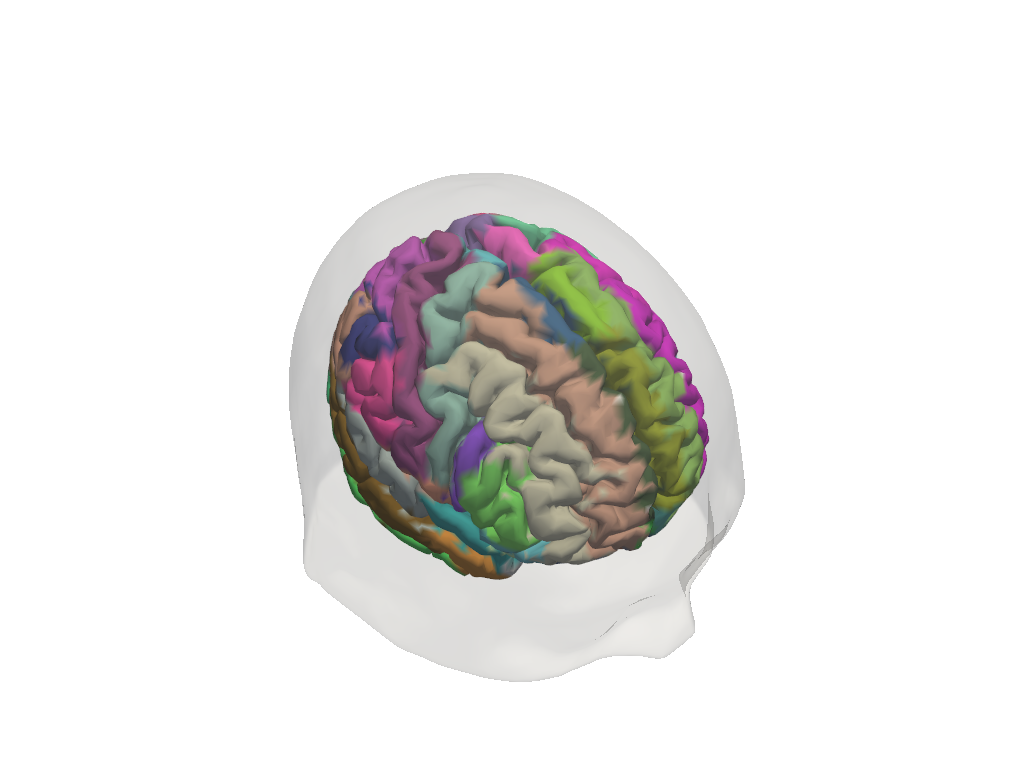

In [9]:
head_colin = cedalion.dot.get_standard_headmodel("colin27")
colors_colin = colors_for_vertices(df_colin)

plt = pv.Plotter()
vbx.plot_surface(plt, head_colin.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_colin.brain, color=colors_colin)
plt.show()

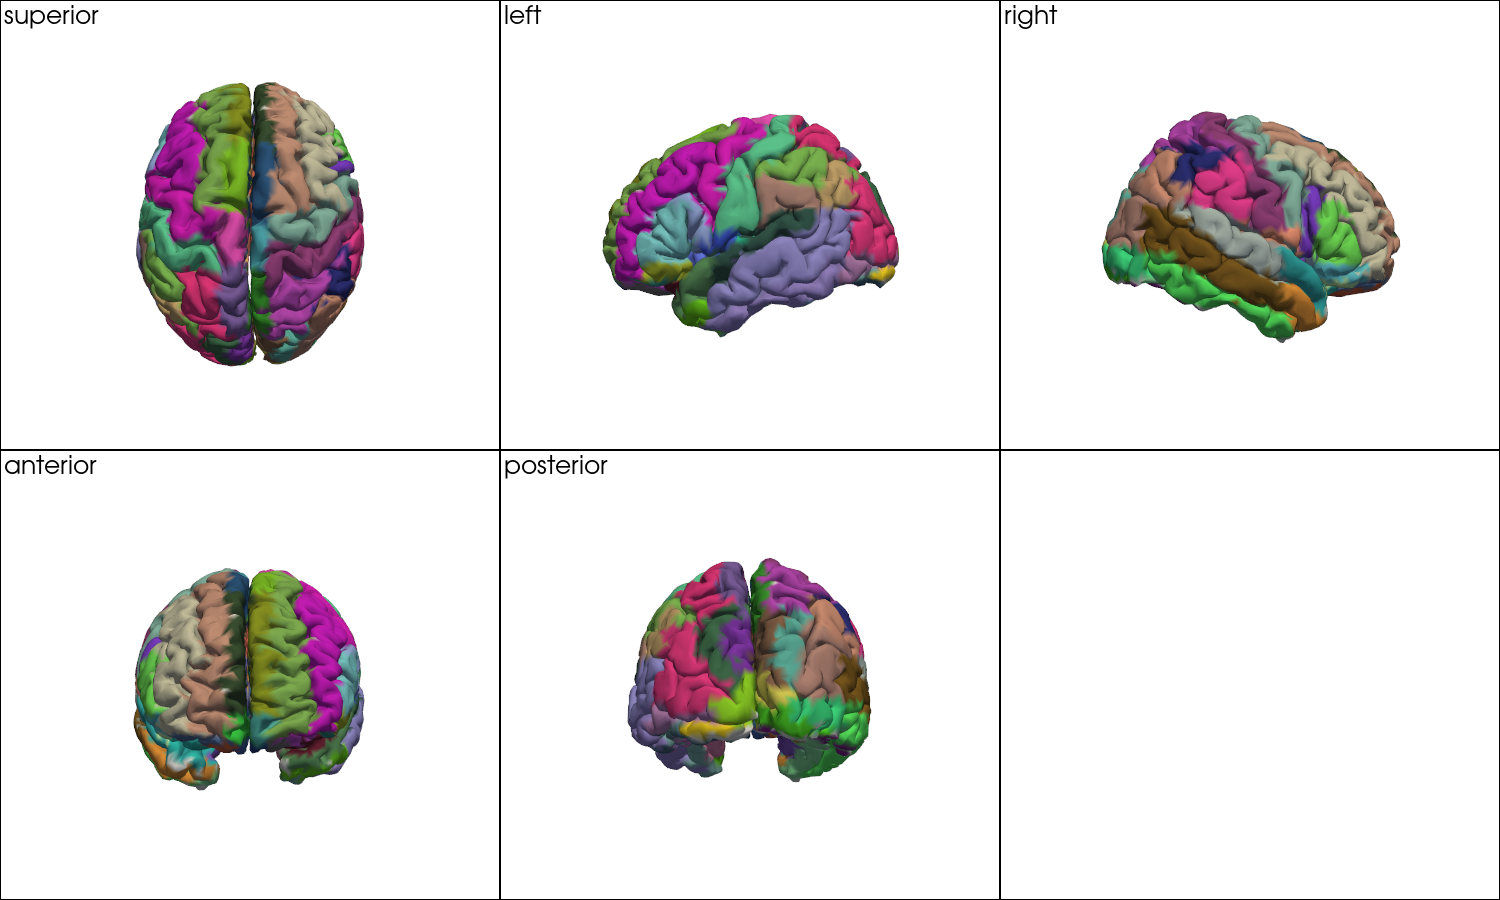

In [10]:
plot_brain_views_grid(head_colin, colors_colin)

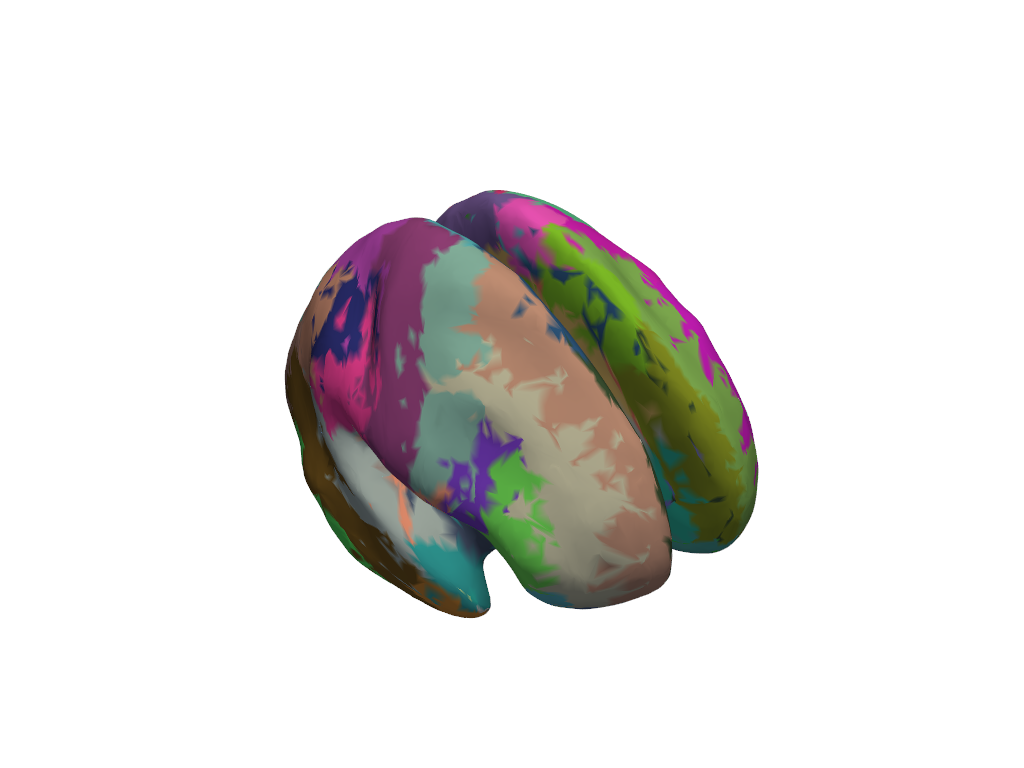

In [11]:
infl_colin = cedalion.dot.get_inflated_cortex_surface("colin27")

plt = pv.Plotter()
vbx.plot_surface(plt, infl_colin, color=colors_colin)
plt.show()

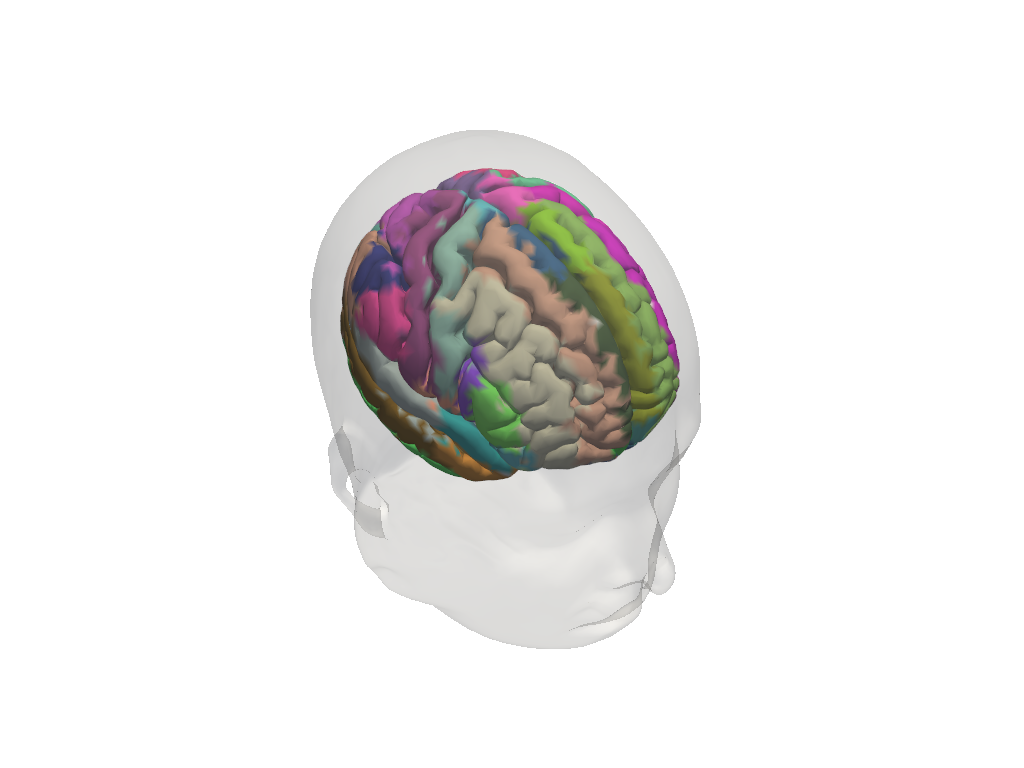

In [12]:
head_icbm = cedalion.dot.get_standard_headmodel("icbm152")
colors_icbm_surface = colors_for_vertices(df_icbm_surface_nearest)

plt = pv.Plotter()
vbx.plot_surface(plt, head_icbm.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_icbm.brain, color=colors_icbm_surface)
plt.show()

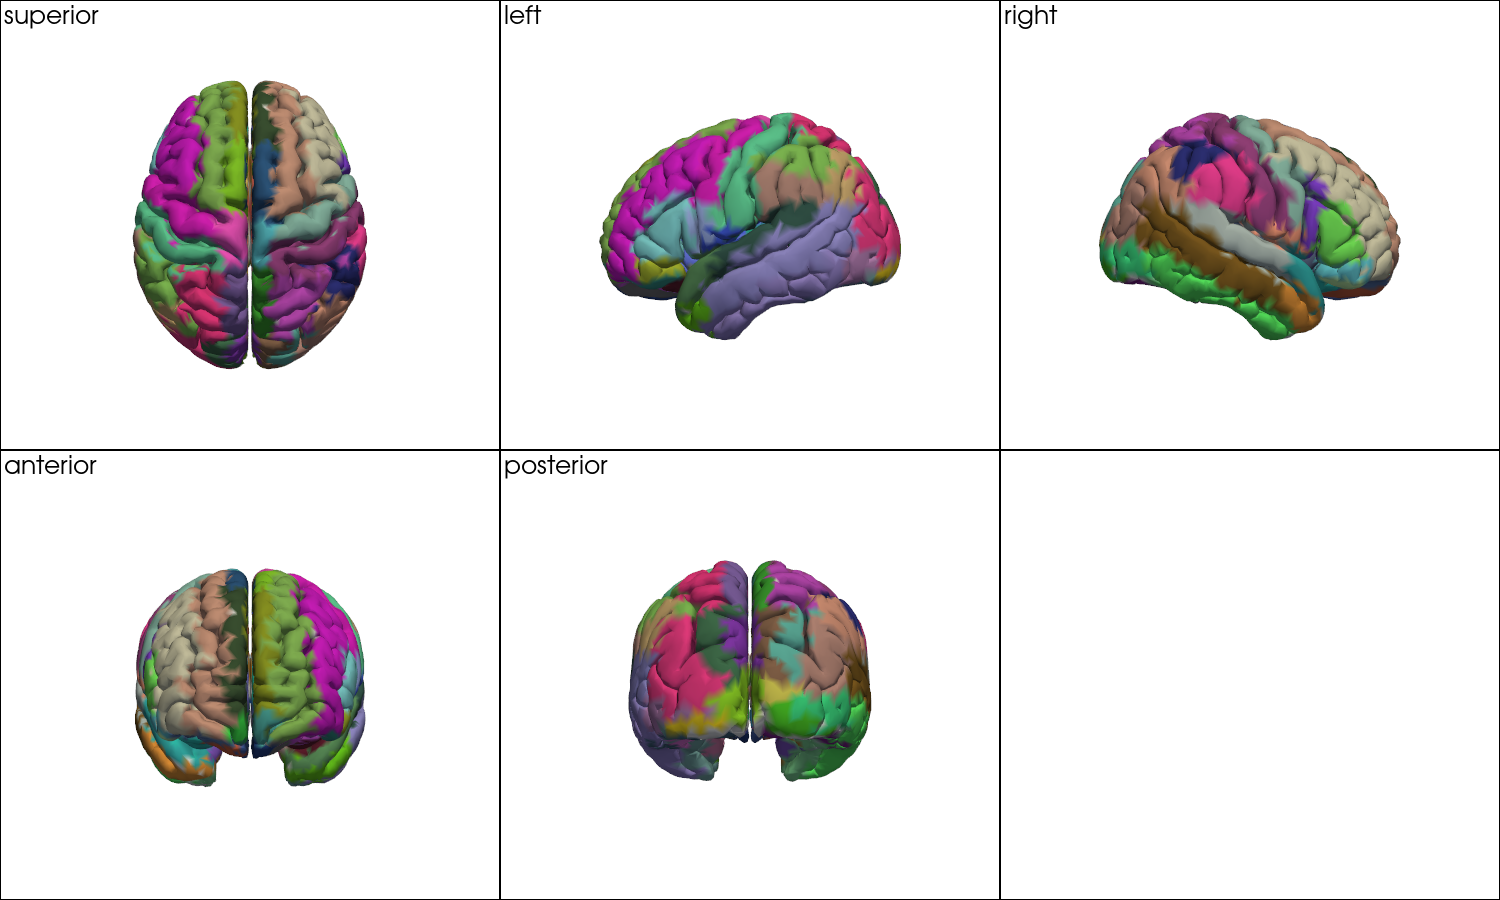

In [13]:
plot_brain_views_grid(head_icbm, colors_icbm_surface)

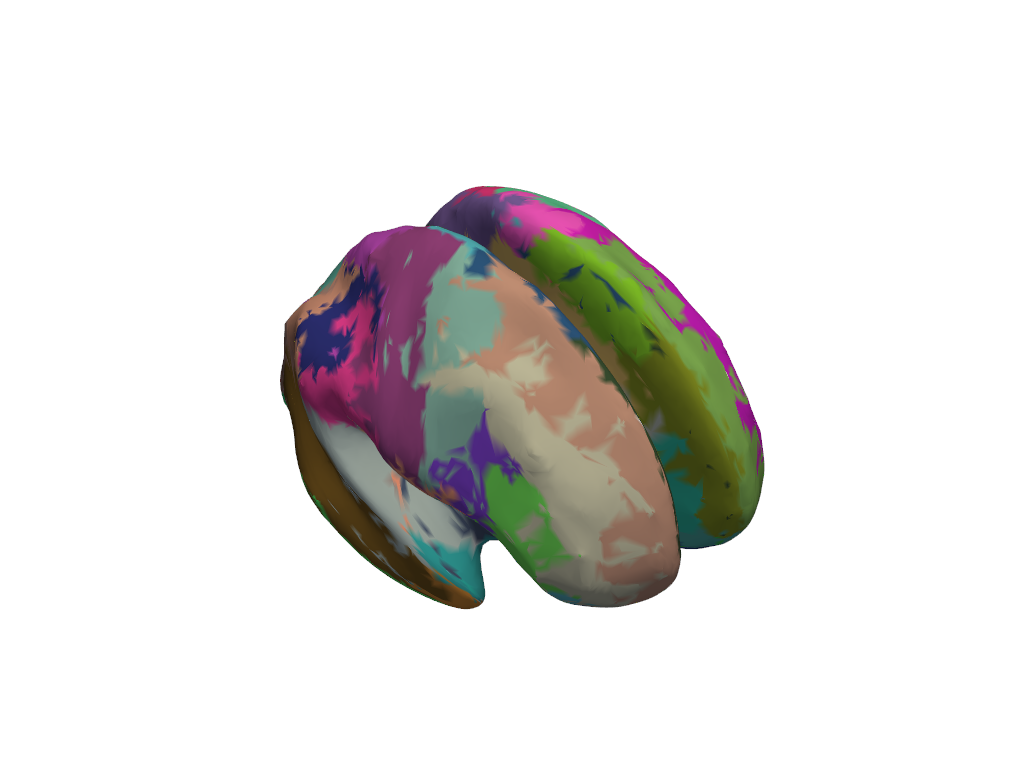

In [14]:
infl_icbm = cedalion.dot.get_inflated_cortex_surface("icbm152")

plt = pv.Plotter()
vbx.plot_surface(plt, infl_icbm, color=colors_icbm_surface)
plt.show()

### Highlighting A Single AAL ROI

If you want to inspect one exact AAL region instead of the full atlas, set the ROI name directly and plot only that region on the pial and inflated surfaces.

In [ ]:
target_model = "colin27"  # or "icbm152"
target_aal = "Frontal_Inf_Oper_R"  # or any other AAL ROI name


def colors_for_single_aal_roi(df, roi_name, roi_color=None, background=(210, 210, 210)):
    df_sorted = df.sort_values("vertex")
    available_names = set(df_sorted["aal_name"])

    if roi_name not in available_names:
        matches = sorted(name for name in available_names if roi_name.lower() in name.lower())
        if matches:
            raise ValueError(
                f"Unknown AAL ROI '{roi_name}'. Try one of: {matches[:10]}"
            )
        raise ValueError(f"Unknown AAL ROI '{roi_name}'.")

    if roi_color is None:
        roi_color = tuple(int(v) for v in aal_colors.get(roi_name, (230, 80, 60)))

    return np.asarray(
        [roi_color if name == roi_name else background for name in df_sorted["aal_name"].values],
        dtype=np.uint8,
    )


model_lookup = {
    "colin27": (head_colin, infl_colin, df_colin),
    "icbm152": (head_icbm, infl_icbm, df_icbm_surface_nearest),
}

if target_model not in model_lookup:
    raise ValueError(f"Unknown model '{target_model}'. Choose from {list(model_lookup)}")

head_single, infl_single, df_single = model_lookup[target_model]
single_roi_colors = colors_for_single_aal_roi(df_single, target_aal)
vertex_count = int((df_single["aal_name"] == target_aal).sum())
print(f"Plotting {target_aal} on {target_model} ({vertex_count} vertices).")

plt = pv.Plotter(shape=(1, 2), window_size=(1200, 500))

plt.subplot(0, 0)
plt.add_text(f"Pial — {target_aal}", position="upper_left", font_size=10)
vbx.plot_surface(plt, head_single.brain, color=single_roi_colors)

plt.subplot(0, 1)
plt.add_text(f"Inflated — {target_aal}", position="upper_left", font_size=10)
vbx.plot_surface(plt, infl_single, color=single_roi_colors)

plt.show()

ValueError: Unknown AAL ROI 'Inferior_Frontal_Gyrus_R'.

## Use AAL as the ROI coordinate in image reconstruction

Cedalion's reconstruction code currently propagates a vertex coordinate named `parcel`. To make AAL behave like the built-in Schaefer parcels, copy the AAL names into `head.brain.vertex_coords['parcel']` before constructing/running image reconstruction objects.

In [16]:
head_colin_aal = cedalion.dot.get_standard_headmodel("colin27")
head_colin_aal.brain.vertex_coords["aal_index"] = df_colin.sort_values("vertex")["aal_index"].values
head_colin_aal.brain.vertex_coords["aal_name"] = df_colin.sort_values("vertex")["aal_name"].values

# Optional: overwrite the generic parcel coordinate so existing Cedalion parcel code groups by AAL.
# head_colin_aal.brain.vertex_coords["parcel"] = head_colin_aal.brain.vertex_coords["aal_name"]